Early stopping at epoch 101
Train R²: 0.5195
Test  R²: 0.4666
R² Gap (Train - Test): 0.0529
Train RMSE: 155.5448
Test  RMSE: 170.2488
RMSE Gap (Test - Train): 14.7040


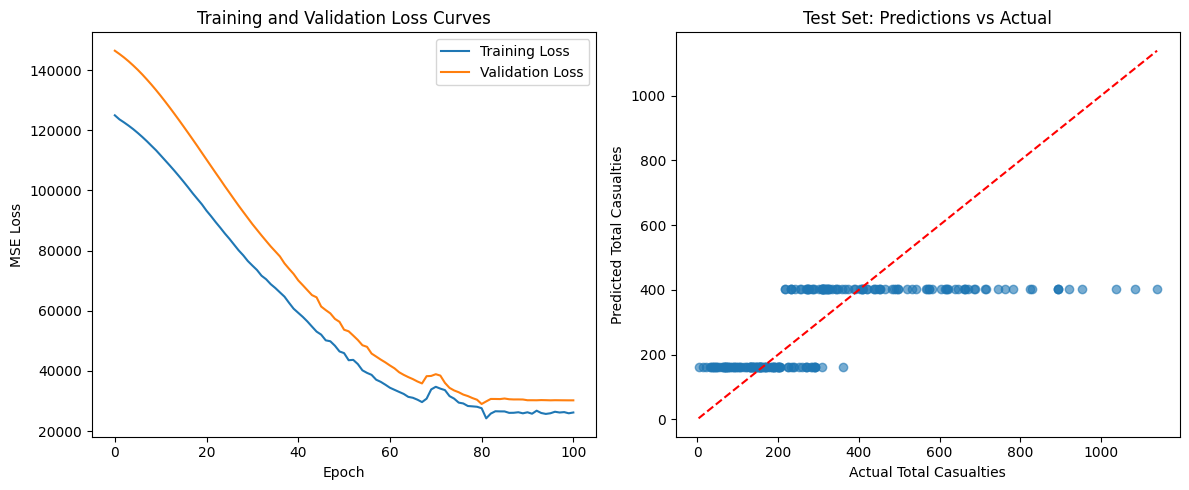

In [2]:
import subprocess
import sys
try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import DataLoader, TensorDataset
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "torch"])
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import DataLoader, TensorDataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('Augmented Dataset of Nigeria Crash.csv')
categorical_cols = ['Quarter', 'State', 'Region']
numerical_cols = [c for c in df.columns if c not in categorical_cols + ['Quarter_Date', 'State_Encoded']]
numerical_cols = [c for c in numerical_cols if df[c].dtype in ['float64', 'int64']]
df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].median())
for col in categorical_cols:
    df[col] = df[col].fillna('Unknown')
    le = LabelEncoder()
    df[col+'_code'] = le.fit_transform(df[col].astype(str))
cat_encoded_cols = [col+'_code' for col in categorical_cols]
all_features = numerical_cols + cat_encoded_cols
target = 'Total_Casualties'
X = df[all_features].copy()
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_num = X_train[numerical_cols].values
X_test_num = X_test[numerical_cols].values
X_train_num_scaled = scaler.fit_transform(X_train_num)
X_test_num_scaled = scaler.transform(X_test_num)
X_train_cat = X_train[cat_encoded_cols].values
X_test_cat = X_test[cat_encoded_cols].values
X_train_combined = np.hstack([X_train_num_scaled, X_train_cat])
X_test_combined = np.hstack([X_test_num_scaled, X_test_cat])
X_train_tensor = torch.tensor(X_train_combined, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_combined, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

class TabTransformer(nn.Module):
    def __init__(self, input_dim, num_heads=8, num_layers=3, ff_dim=128, dropout=0.1):
        super().__init__()
        self.embedding = nn.Linear(input_dim, ff_dim)
        self.pos_encoder = PositionalEncoding(ff_dim)
        encoder_layer = nn.TransformerEncoderLayer(d_model=ff_dim, nhead=num_heads, dim_feedforward=ff_dim*4, dropout=dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(ff_dim)
        self.fc_out = nn.Linear(ff_dim, 1)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x):
        x = self.embedding(x).unsqueeze(1)
        x = self.pos_encoder(x)
        x = self.transformer(x)
        x = self.norm(x)
        x = x.mean(dim=1)
        x = self.dropout(x)
        return self.fc_out(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = TabTransformer(input_dim=X_train_combined.shape[1], num_heads=8, num_layers=4, ff_dim=128, dropout=0.2).to(device)
criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)
num_epochs = 200
train_losses = []
val_losses = []
best_val_loss = float('inf')
patience_counter = 0
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * batch_x.size(0)
    train_loss /= len(train_loader.dataset)
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item() * batch_x.size(0)
    val_loss /= len(test_loader.dataset)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_tabtransformer.pth')
    else:
        patience_counter += 1
        if patience_counter >= 20:
            print(f'Early stopping at epoch {epoch+1}')
            break
model.load_state_dict(torch.load('best_tabtransformer.pth'))
model.eval()
with torch.no_grad():
    train_pred = model(X_train_tensor.to(device)).cpu().numpy().flatten()
    test_pred = model(X_test_tensor.to(device)).cpu().numpy().flatten()
train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
gap_r2 = train_r2 - test_r2
gap_rmse = test_rmse - train_rmse
print(f"Train R²: {train_r2:.4f}")
print(f"Test  R²: {test_r2:.4f}")
print(f"R² Gap (Train - Test): {gap_r2:.4f}")
print(f"Train RMSE: {train_rmse:.4f}")
print(f"Test  RMSE: {test_rmse:.4f}")
print(f"RMSE Gap (Test - Train): {gap_rmse:.4f}")
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training and Validation Loss Curves')
plt.legend()
plt.subplot(1, 2, 2)
plt.scatter(y_test, test_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Total Casualties')
plt.ylabel('Predicted Total Casualties')
plt.title('Test Set: Predictions vs Actual')
plt.tight_layout()
plt.savefig('tabtransformer_results.png', dpi=150)
plt.show()
try:
    attn_weights = []
    def hook_fn(module, input, output):
        attn_weights.append(output[1].detach().cpu())
    for layer in model.transformer.layers:
        layer.self_attn.register_forward_hook(hook_fn)
    with torch.no_grad():
        _ = model(X_train_tensor[:1].to(device))
    if attn_weights:
        avg_attn = attn_weights[0].mean(dim=1).squeeze().numpy()
        plt.figure(figsize=(10, 6))
        sns.heatmap(avg_attn, cmap='viridis', cbar=True)
        plt.title('Average Attention Weights (First Layer)')
        plt.tight_layout()
        plt.savefig('attention_weights.png', dpi=150)
        plt.show()
except:
    pass